## Train the PF-Controller Neural Network

For each performance metric, train the corresponding particle-filter (PF) controller neural network.

In [1]:
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
import torch.nn as nn
from src.models.particle_filter.core import ParticleFilter
from src.models.networks.pf_mlp import ParticleFilterMLP
from src.helpers.seed import set_global_seed

from experiment_config import (
    DegModel,DATA_NAME,SEED,LEAKY_SLOPE,HIDDEN_DIMS,PREDICTION_START_IDX,LOSS_TAIL_SIZE,N_PARTICLES,GRADIENT_CLIP,WEIGHT_DECAY,PFNET_DIR,DEGR_MODEL_DIR,ESTIMATION_DIR,LOSS_WINDOW,AVERSION,CURRENT_OBS
)
    
DATA_NAME

'DS06'

## Task

In [2]:
perform_name = 'SmFan'

## Hyper-Parameters

In [3]:
# Training parameters#
# optimization
lr = 5e-4

# Early stopping
max_epochs = 300
min_epochs = 100
patience = 40     # how many eval steps to wait
min_delta = 0.01      # minimum improvement to count

In [4]:
activation = nn.LeakyReLU(LEAKY_SLOPE)

set_global_seed(SEED)
PERFORM_DIR = PFNET_DIR/perform_name

checkpoint_best_path = PERFORM_DIR / "checkpoint_best.pt"
checkpoint_last_path = PERFORM_DIR / "checkpoint_last.pt"
checkpoint_best_path.parent.mkdir(parents=True, exist_ok=True)

## Import training data

In [5]:
hi_df = pd.read_csv(ESTIMATION_DIR/"data_dev.csv")
units = hi_df['unit'].astype(int).unique().tolist()
units 

[1, 2, 3, 4, 5, 6]

### Extract degradation onset

In [6]:
onsets = {unit: hi_df[(hi_df['unit']==unit) & (hi_df['hs']==0)]['cycle'].values[0] for unit in units}
del hi_df['hs']

In [7]:
perform_names = [col for col in hi_df.columns if col not in ['unit','cycle']]

performs = {name: 
    {unit: hi_df[hi_df['unit']==unit][name].values for unit in units} 
    for name in perform_names
}

init_ss = {name: {unit: perform[unit].max() for unit in units} for name,perform in performs.items()}
time = {unit: hi_df[hi_df['unit']==unit]['cycle'].values for unit in units}

## Create component (base) models

In [8]:
dev_data = {}
dev_eol = {}
for unit in units:
    t = time[unit]
    s = performs[perform_name][unit]
    dev_data[unit]=torch.tensor(np.stack([t, s],axis=1),dtype=torch.float32)
    dev_eol[unit]=torch.tensor(t[-1],dtype=torch.float32) 


In [9]:
dev_degmodels = {}
for unit, perform in performs[perform_name].items():
	best_model = DegModel(onset=onsets[unit], init_s=init_ss[perform_name][unit])
	best_model.load_state_dict(
		torch.load(DEGR_MODEL_DIR/'states'/perform_name/f'unit_{unit}'/ "best_model.pt")
	)
	dev_degmodels[unit] = best_model

## Train Particle Filter controller Net

In [10]:
net = ParticleFilterMLP(state_dim=DegModel.state_dim(), hidden_dims=HIDDEN_DIMS,
                        activation=lambda : nn.LeakyReLU(LEAKY_SLOPE))

optimizer = torch.optim.Adam(net.parameters(), lr, weight_decay=WEIGHT_DECAY)
optimizer.zero_grad()

In [11]:
best_score = float("inf")
train_epoch_losses = []
eval_epoch_losses = []
scores = []
window_means = []
window_stds = []
wait = 0
start_epoch = 0

if checkpoint_last_path.exists():
    ckpt = torch.load(checkpoint_last_path, weights_only=False)

    net.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    start_epoch = ckpt["epoch"] + 1
    best_score = ckpt["best_score"]
    scores = ckpt.get("scores", [])
    train_epoch_losses = ckpt.get("train_losses", [])
    eval_epoch_losses = ckpt.get("eval_losses", [])
    window_means = ckpt.get("window_means", [])
    window_stds = ckpt.get("window_stds", [])

    torch.random.set_rng_state(ckpt["rng_torch"])
    np.random.set_state(ckpt["rng_numpy"])

    print(f"✓ Resumed from epoch {start_epoch}, best_score={best_score:.3f}")


In [12]:
for epoch in range(start_epoch, max_epochs):

    eval_fold_losses = []
    train_fold_losses = []

    for eval_unit in np.random.permutation(units):
        train_unit_losses = []

        # --------------------------
        # TRAINING
        # --------------------------
        for train_unit in np.random.permutation(units):

            if train_unit == eval_unit:
                continue

            train_offline_units = [
                u for u in units if u not in (train_unit, eval_unit)
            ]

            train_offline_degmodels = [
                dev_degmodels[u] for u in train_offline_units
            ]

            train_t_data = dev_data[train_unit][:, 0]
            train_s_data = dev_data[train_unit][:, 1]

            optimizer.zero_grad()

            train_pf = ParticleFilter(
                base_models=train_offline_degmodels,
                net=net,
                n_particles=N_PARTICLES,
            ).train()
            
            train_step_losses = []
            for k in range(PREDICTION_START_IDX, len(train_t_data)):
                start_obs = k if CURRENT_OBS else 0
                train_mixture_dist = train_pf.step(
                    t_obs=train_t_data[start_obs:k + 1],
                    s_obs=train_s_data[start_obs:k + 1],
                )

                start_loss = -LOSS_TAIL_SIZE if LOSS_TAIL_SIZE else k
                train_last_dist = train_mixture_dist.distribution(
                    s=train_s_data[start_loss:]
                )
                train_step_nll = -train_last_dist.log_prob(
                    train_t_data[start_loss:]
                ).mean()

                train_step_losses.append(train_step_nll)

            train_unit_loss = torch.stack(train_step_losses).mean()

            train_unit_loss.backward()

            if GRADIENT_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(
                    net.parameters(), GRADIENT_CLIP
                )

            optimizer.step()

            train_unit_losses.append(train_unit_loss.item())

        train_fold_loss = np.mean(train_unit_losses)
        train_fold_losses.append(train_fold_loss)

        # --------------------------
        # EVALUATION
        # --------------------------

        eval_offline_units = [u for u in units if u != eval_unit]

        eval_offline_degmodels = [
            dev_degmodels[u] for u in eval_offline_units
        ]

        eval_t_data = dev_data[eval_unit][:, 0]
        eval_s_data = dev_data[eval_unit][:, 1]

        eval_pf = ParticleFilter(
            base_models=eval_offline_degmodels,
            net=net,
            n_particles=N_PARTICLES,
        ).eval()

        eval_step_losses = []
        for k in range(PREDICTION_START_IDX, len(eval_t_data)):

            start_obs = k if CURRENT_OBS else 0
            eval_mixture_dist = eval_pf.step(
                t_obs=eval_t_data[start_obs:k + 1],
                s_obs=eval_s_data[start_obs:k + 1],
            )

            start_loss = -LOSS_TAIL_SIZE if LOSS_TAIL_SIZE else k

            eval_last_dist = eval_mixture_dist.distribution(
                s=eval_s_data[start_loss:]
            )

            eval_step_nll = -eval_last_dist.log_prob(
                eval_t_data[start_loss:]
            ).mean()

            eval_step_losses.append(eval_step_nll.item())

        eval_fold_loss = np.mean(eval_step_losses)
        eval_fold_losses.append(eval_fold_loss)

    # --------------------------
    # epoch statistics
    # --------------------------

    train_epoch_loss = np.mean(train_fold_losses)
    eval_epoch_loss = np.mean(eval_fold_losses)

    train_epoch_losses.append(train_epoch_loss)
    eval_epoch_losses.append(eval_epoch_loss)



    # --------------------------
    # VARIANCE-AWARE SELECTION
    # --------------------------


    window = eval_epoch_losses[-LOSS_WINDOW:]
    mean_loss = np.mean(window)
    std_loss = np.std(window)
    window_means.append(mean_loss)
    window_stds.append(std_loss)

    score = mean_loss + AVERSION * std_loss
    scores.append(score)
    
    print(
        f"[Epoch {epoch:04d}] "
        f"train={train_epoch_loss:.3f} | "
        f"eval={eval_epoch_loss:.3f} | "
        f"score={score:.3f} "
        f"(μ={mean_loss:.3f}, σ={std_loss:.3f})"
    )


    # --------------------------
    # CHECKPOINT SELECTION
    # --------------------------

    if (epoch + 1 >= LOSS_WINDOW): 
        if (score < best_score - min_delta):

            best_score = score
            wait = 0

            best_checkpoint = {
                "epoch": epoch,
                "model_state": net.state_dict(),
                "best_score": best_score,
            }

            torch.save(best_checkpoint, checkpoint_best_path)

            last_checkpoint = {
                "epoch": epoch,
                "model_state": net.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_score": best_score,
                "scores": scores,
                "train_losses": train_epoch_losses,
                "eval_losses": eval_epoch_losses,
                "window_means": window_means,
                "window_stds": window_stds,
                "rng_torch": torch.random.get_rng_state(),
                "rng_numpy": np.random.get_state(),
            }

            torch.save(last_checkpoint, checkpoint_last_path)

            print(f"  + saved (score={score:.3f})")
        else:
            wait += 1

            if epoch >= max(min_epochs, LOSS_WINDOW) and wait >= patience:
                print("🛑 Early stopping triggered")
                break


[Epoch 0000] train=4.510 | eval=4.157 | score=4.157 (μ=4.157, σ=0.000)
[Epoch 0001] train=3.919 | eval=3.885 | score=4.089 (μ=4.021, σ=0.136)
[Epoch 0002] train=3.938 | eval=7.889 | score=6.224 (μ=5.310, σ=1.827)
[Epoch 0003] train=3.876 | eval=3.797 | score=5.788 (μ=4.932, σ=1.713)
[Epoch 0004] train=3.866 | eval=3.847 | score=5.511 (μ=4.715, σ=1.592)
[Epoch 0005] train=3.834 | eval=3.790 | score=5.308 (μ=4.561, σ=1.494)
[Epoch 0006] train=3.789 | eval=3.829 | score=5.159 (μ=4.456, σ=1.406)
[Epoch 0007] train=3.770 | eval=3.669 | score=5.028 (μ=4.358, σ=1.341)
[Epoch 0008] train=3.737 | eval=3.685 | score=4.924 (μ=4.283, σ=1.282)
[Epoch 0009] train=3.711 | eval=3.611 | score=4.832 (μ=4.216, σ=1.233)
  + saved (score=4.832)
[Epoch 0010] train=3.679 | eval=3.590 | score=4.783 (μ=4.159, σ=1.247)
  + saved (score=4.783)
[Epoch 0011] train=3.693 | eval=3.636 | score=4.762 (μ=4.134, σ=1.255)
  + saved (score=4.762)
[Epoch 0012] train=3.679 | eval=3.620 | score=3.754 (μ=3.707, σ=0.093)
  + s

# Save last results

In [13]:
if start_epoch < max_epochs:
    last_checkpoint = {
        "epoch": epoch,
        "model_state": net.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_score": best_score,
        "scores": scores,
        "train_losses": train_epoch_losses,
        "eval_losses": eval_epoch_losses,
        "window_means": window_means,
        "window_stds": window_stds,
        "rng_torch": torch.random.get_rng_state(),
        "rng_numpy": np.random.get_state(),
    }

    torch.save(last_checkpoint, checkpoint_last_path)

    print("✓ Final LAST checkpoint saved.")

else:
    epoch = start_epoch

✓ Final LAST checkpoint saved.


## Plot

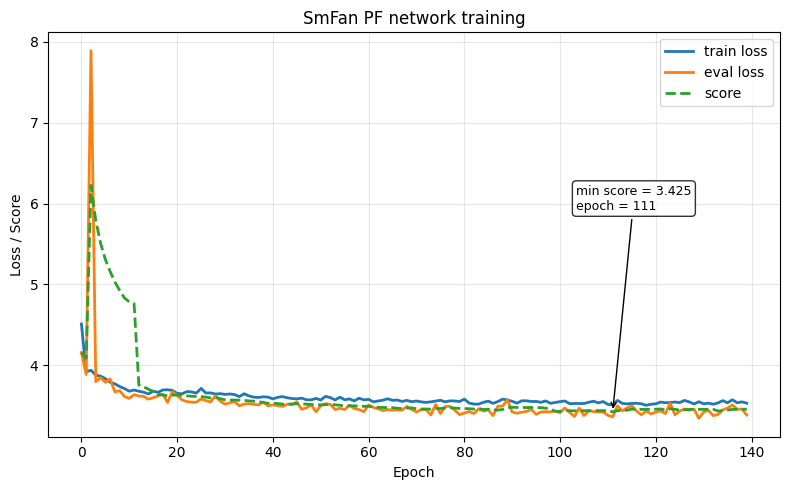

✓ Plot saved to experiments/DS06/opcond_q0.01-0.99_corr0.6_range0.6/estimation_thr0.2/gamma/net256x256x128x64x32_leaky0.05_npar2000_cv_aversion0.5_losswin10_losstail5_currentobs/SmFan/net_training_loss.png
✓ Best epoch: 111 (score=3.4248)


In [14]:
train_loss_arr = np.array(train_epoch_losses)
eval_loss_arr = np.array(eval_epoch_losses)
score_arr = np.array(scores)

epochs = np.arange(len(train_loss_arr))

# best epoch based on score
best_epoch = np.argmin(score_arr)
best_score = score_arr[best_epoch]
best_eval_loss = eval_loss_arr[best_epoch]

plt.figure(figsize=(8, 5))

# Main curves
plt.plot(epochs, train_loss_arr, linewidth=2, label="train loss")
plt.plot(epochs, eval_loss_arr, linewidth=2, label="eval loss")
plt.plot(epochs, score_arr, linewidth=2, linestyle="--", label="score")

ymin, ymax = plt.ylim()
yrange = ymax - ymin

xmin, xmax = plt.xlim()
xrange = xmax - xmin

y_offset = 0.5 * yrange
x_offset = -0.05 * xrange

# Annotation of best score
plt.annotate(
    f"min score = {best_score:.3f}\nepoch = {best_epoch}",
    xy=(best_epoch, best_score),
    xytext=(best_epoch + x_offset, best_score + y_offset),
    textcoords="data",
    arrowprops=dict(arrowstyle="->", linewidth=1),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
)

plt.xlabel("Epoch")
plt.ylabel("Loss / Score")
plt.title(f"{perform_name} PF network training")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure
fig_path = PERFORM_DIR / "net_training_loss.png"
plt.savefig(fig_path, dpi=300)

# Save raw arrays
np.save(PERFORM_DIR / "net_training.npy", train_loss_arr)
np.save(PERFORM_DIR / "net_eval.npy", eval_loss_arr)
np.save(PERFORM_DIR / "net_score.npy", score_arr)

plt.show()

print(f"✓ Plot saved to {fig_path}")
print(f"✓ Best epoch: {best_epoch} (score={best_score:.4f})")